## A) Data Cleaning

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)

In [6]:
raw = pd.read_csv("Salary_dataset.csv")
raw.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [7]:
df = raw.drop(columns=["Unnamed: 0"])
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


## B) Linear Regression model qurish

In [8]:
x = df[["YearsExperience"]]
y = df["Salary"]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state =42)
X_train.shape, X_test.shape

((24, 1), (6, 1))

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (m):     {slope:.2f}")
print(f"Intercept (b): {intercept:.2f}")

Slope (m):     9423.82
Intercept (b): 24380.20


In [10]:
y_pred = model.predict(X_test)

pd.DataFrame({
    "YearsExperience": X_test["YearsExperience"].values,
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred,
}).round(2)

,YearsExperience,Actual Salary,Predicted Salary
0,9.7,112636.0,115791.21
1,5.0,67939.0,71499.28
2,8.3,113813.0,102597.87
3,5.4,83089.0,75268.80
4,3.3,64446.0,55478.79
5,3.8,57190.0,60190.70


## C) Model aniqligini o'lchash

In [11]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R^2:  {r2:.4f}")

NameError: name 'mean_absolute_error' is not defined

### PLOT


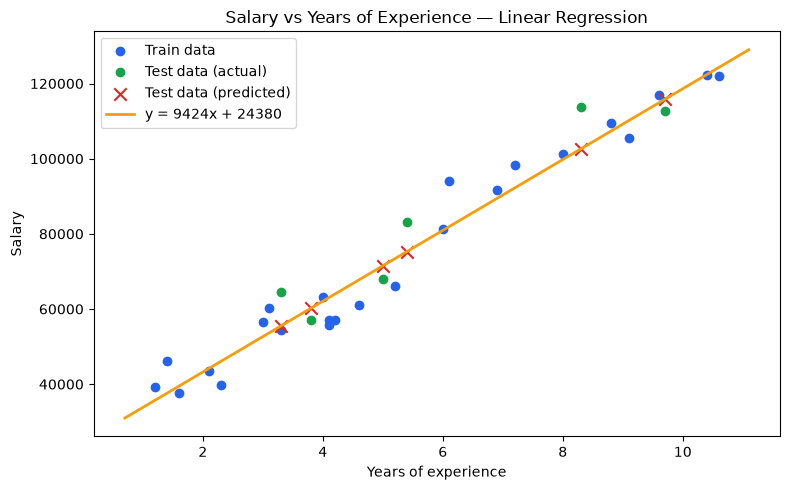

In [10]:
line_x = np.linspace(X["YearsExperience"].min() - 0.5, X["YearsExperience"].max() + 0.5, 50)
line_y = slope * line_x + intercept

plt.figure(figsize=(8, 5))
plt.scatter(X_train, y_train, color="#2563eb", label="Train data")
plt.scatter(X_test, y_test, color="#16a34a", label="Test data (actual)")
plt.scatter(X_test, y_pred, color="#dc2626", marker="x", s=80, label="Test data (predicted)")
plt.plot(line_x, line_y, color="#f59e0b", linewidth=2, label=f"y = {slope:.0f}x + {intercept:.0f}")
plt.xlabel("Years of experience")
plt.ylabel("Salary")
plt.title("Salary vs Years of Experience — Linear Regression")
plt.legend()
plt.tight_layout()
plt.savefig("salary_regression_plot.png", dpi=150)
plt.show()